In [137]:
from __future__ import annotations

from langchain_groq import ChatGroq
import operator
import os
import re
from datetime import date, timedelta
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv

In [138]:
class Task(BaseModel):
    id : Optional[int]
    title : str
    goal : str = Field(... , description="One sentence describing what the reader should do/understand")
    # Field(...)  → "Required field"
    # Field(x)    → "Optional (Default value = x)"
    # Field()     → "Optional (Default = None)"
    # name: str , this is required by default , no need for ...
    bullets : List[str] = Field(... , min_length=3 , max_length=6)
    target_words : int = Field(... , description="Target words (120 - 550).")

    tags : List[str] = Field(default_factory=list)
    # if u do tags : List[str] = []
    # every instance of this class will get the same list , every instance shares the same list , so if u change the list via one instance , it will affect others.
    # for each instance to have their separate list we use default_factory
    # Each workflow run gets its own memory list
    requires_research : bool = False
    requires_citations : bool = False
    requires_code : bool = False


class Plan(BaseModel):
    blog_title : str
    audience : str
    tone : str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks : List[Task]


class EvidenceItem(BaseModel):
    title : str
    url : str
    published_at : Optional[str] = None
    snippet : Optional[str] = None
    source : Optional[str] = None


class RouterDecision(BaseModel):
    needs_research : bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    reason : str
    queries : List[str] = Field(default_factory=list)
    max_results_per_query: int = Field(5)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


class ImageSpec(BaseModel):
    placeholder : str = Field(... , description="e.g. [[IMAGE_1]]")
    filename : str = Field(..., description="Save under images/, e.g. picture.png")
    alt : str
    caption : str
    prompt : str = Field(... , description = "Prompt to send to the image model")
    size: Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality: Literal["low", "medium", "high"] = "medium"


class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)





class State(TypedDict):
    topic: str


    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]


    as_of: str
    recency_days: int

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    # Annotated[type , metadata]

    # if 2 nodes sets 
    # {"sections": [(1, "Intro")]}
    # {"sections": [(2, "Body")]}

    # sections = [(2, "Body")]   # ❌ overwrites previous

    # With operator.add
    # Now:
    
    # sections = [(1, "Intro")] + [(2, "Body")]
    # 👉 Result:
    # [(1, "Intro"), (2, "Body")]


    
    merged_md: str
    md_with_placeholders: str
    image_specs: List[dict]

    final: str




    

In [139]:
llm = ChatGroq(
        api_key=os.getenv("GROQ_API_KEY", "").strip(),
        model="llama-3.3-70b-versatile",
        )

In [140]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false): evergreen concepts.
- hybrid (needs_research=true): evergreen + needs up-to-date examples/tools/models.
- open_book (needs_research=true): volatile weekly/news/"latest"/pricing/policy.

If needs_research=true:
- Output 3–10 high-signal, scoped queries.
- For open_book weekly roundup, include queries reflecting last 7 days.
"""

In [141]:
def router_node(state : State) -> State:
    structured_llm = llm.with_structured_output(RouterDecision)

    decision : RouterDecision = structured_llm.invoke(
        [
            SystemMessage(content = ROUTER_SYSTEM),
            HumanMessage(content = f"Topic : {state['topic']}\n As-of date: {state['as_of']}")            
        ]
    )

    if decision.mode == "open_book":
        recency_days = 7
    elif decision.mode == "hybrid":
        recency_days = 45
    else:
        recency_days = 3650

    return{
        "needs_research" : decision.needs_research,
        "mode" : decision.mode,
        "queries" : decision.queries,
        "recency_days" : recency_days
    }


def route_next(state : State) -> str:
    return "research" if state["needs_research"] else "orchestrator"


def tavily_search(query : str , max_results : int = 5) -> List[dict]:
    try:
        from langchain.community.tools.tavily_search import TavilySearchResults
        tool = TavilySearchResults(max_results = max_results)
        results = tool.invoke({"query" : query})

        out : List[dict] = []

        for r in results:
            out.append(
                {
                    "title": r.get("title") or "",
                    "url": r.get("url") or "",
                    "snippet": r.get("content") or r.get("snippet") or "",
                    "published_at": r.get("published_date") or r.get("published_at"),
                    "source": r.get("source"),
                }
            )
        return out
    except Exception:
        return []
    

def _iso_to_date(s: Optional[str]) -> Optional[date]:
    if not s:
        return None
    try:
        return date.fromisoformat(s[:10])
    except Exception:
        return None



In [142]:

RESEARCH_SYSTEM = """You are a research synthesizer.

Given raw web search results, produce EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources.
- Normalize published_at to ISO YYYY-MM-DD if reliably inferable; else null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""

In [143]:
def research_node(state : State) -> State:
    queries = state['queries'] or []
    raw : List[dict] = []

    for q in queries:
        raw.extend(tavily_search(q , max_results=6))

    if not raw:
        return {'evidence' : []}
    
    structured_llm = llm.with_structured_output(EvidencePack)
    pack : EvidencePack = structured_llm.invoke(
        [
            SystemMessage(content = RESEARCH_SYSTEM),
            HumanMessage(
                content = (
                    f"As-of data : {state['as_of']}\n"
                    f"Recency days : {state['recency_days']}\n\n"
                    f"Raw results:\n {raw}"
                )
            ),
        ]
    )

    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    evidence = list(dedup.values())

    if state.get("mode") == "open_book":
        as_of = date.fromisoformat(state["as_of"])
        cutoff = as_of - timedelta(days=int(state["recency_days"]))
        evidence = [e for e in evidence if (d := _iso_to_date(e.published_at)) and d >= cutoff]

    return {"evidence": evidence}

    

In [144]:
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Produce a highly actionable outline for a technical blog post.

Requirements:
- 5–9 tasks, each with goal + 3–6 bullets + target_words.
- Tags are flexible; do not force a fixed taxonomy.

Grounding:
- closed_book: evergreen, no evidence dependence.
- hybrid: use evidence for up-to-date examples; mark those tasks requires_research=True and requires_citations=True.
- open_book: weekly/news roundup:
  - Set blog_kind="news_roundup"
  - No tutorial content unless requested
  - If evidence is weak, plan should explicitly reflect that (don’t invent events).

Output must match Plan schema.
"""

In [145]:
def orchestrator_node(state : State) -> State:
    structured_llm = llm.with_structured_output(Plan)
    mode = state['mode'] or "closed_book"
    evidence = state.get('evidence', []) or []
    #  If "evidence" key is missing, return []
    # or [] => If the value is falsy, replace it with []

    forced_kind = "news_roundup" if mode == "open_book" else None

    plan : Plan = structured_llm.invoke(
        [
            SystemMessage(content = ORCH_SYSTEM),
            HumanMessage(
                content = (
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {state['as_of']} (recency_days={state['recency_days']})\n"
                    f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                    f"Evidence:\n{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )

    if forced_kind:
        plan.blog_kind = "news_roundup"

    return {'plan' : plan}


In [146]:
def fanout(state : State):
    assert state['plan'] is not None
    return [
        Send(
            'worker',
            {
                "task": task.model_dump(),
                # converted object to a dict using model_dump
                # because we cant send 
                # LangGraph state must be serializable
                # Objects (like Pydantic models) aren’t always safely passed across nodes
                # 👉 So we:
                # serialize → send → reconstruct
                "topic": state["topic"],
                "mode": state["mode"],
                "as_of": state["as_of"],
                "recency_days": state["recency_days"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state['plan'].tasks
    ]

In [147]:
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Constraints:
- Cover ALL bullets in order.
- Target words ±15%.
- Output only section markdown starting with "## <Section Title>".

Scope guard:
- If blog_kind=="news_roundup", do NOT drift into tutorials (scraping/RSS/how to fetch).
  Focus on events + implications.

Grounding:
- If mode=="open_book": do not introduce any specific event/company/model/funding/policy claim unless supported by provided Evidence URLs.
  For each supported claim, attach a Markdown link ([Source](URL)).
  If unsupported, write "Not found in provided sources."
- If requires_citations==true (hybrid tasks): cite Evidence URLs for external claims.

Code:
- If requires_code==true, include at least one minimal snippet.
"""

In [148]:
def worker_node(payload : dict) -> dict:
    task = Task(**payload["task"])
    # converting dict to object
    plan = Plan(**payload['plan'])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]


    bullets_text = "\n- " + "\n- ".join(task.bullets)
    evidence_text = "\n".join(
        f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}"
        for e in evidence[:20]
    )

    section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {payload['topic']}\n"
                    f"Mode: {payload.get('mode')}\n"
                    f"As-of: {payload.get('as_of')} (recency_days={payload.get('recency_days')})\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY cite these URLs):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}


In [149]:
graph = StateGraph(State)
graph.add_node("router", router_node)
graph.add_node("research", research_node)
graph.add_node("orchestrator", orchestrator_node)
graph.add_node("worker", worker_node)

graph.add_edge(START, "router")
graph.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
graph.add_edge("research", "orchestrator")

graph.add_conditional_edges("orchestrator", fanout, ["worker"])
graph.add_edge("worker", END)

In [150]:
workflow = graph.compile()

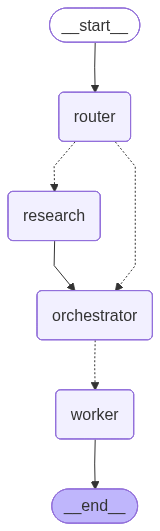

In [151]:
workflow

In [152]:
initial_state = {
    'topic' : 'self-attention',
    'as_of' : '07/08/2004'
}

In [153]:
result = workflow.invoke(initial_state)

In [154]:
# Fan-out = one node → multiple parallel executions

# Instead of a linear flow:

# A → B → C
# You branch out:

#         → B1 →
# A →     → B2 → → C (merge later)
#         → B3 →
# 👉 One state splits into multiple independent states, processed in parallel.

# 🧠 Why use fan-out?
# Run multiple LLM calls in parallel

# Process lists (documents, queries, sections)

# Speed up workflows

# Enable map-reduce style pipelines

In [155]:
# Send is the mechanism that actually performs fan-out.

# It lets you dynamically say:

# “For this node, create multiple parallel executions with different inputs.”

# 🔧 Syntax Concept
# from langgraph.graph import Send

# def fanout_node(state):
#     return [
#         Send("next_node", {"input": item})
#         for item in state["items"]
#     ]
# ⚙️ What happens internally?
# If:

# state["items"] = ["A", "B", "C"]
# Then:

# fanout_node(state)
# returns:

# Send → next_node with "A"
# Send → next_node with "B"
# Send → next_node with "C"
# 👉 LangGraph runs 3 parallel executions of next_node

In [156]:
# def fanout(state):
#     return [Send("worker", {"item": item}) for item in state["items"]]


# def worker(state):
#     return {"results": [state["item"].upper()]}

In [157]:
# A fan-out node does NOT directly return the next node
# 👉 It returns Send objects that tell LangGraph to execute the next node multiple times

In [158]:
# 🔧 What your fan-out node actually returns
# from langgraph.graph import Send

# def fanout(state):
#     return [
#         Send("next_node", {"item": item})
#         for item in state["items"]
#     ]
# If:
# state["items"] = ["A", "B", "C"]
# Then this node returns:
# [
#     Send("next_node", {"item": "A"}),
#     Send("next_node", {"item": "B"}),
#     Send("next_node", {"item": "C"})
# ]
# 🚀 What LangGraph does with this
# LangGraph interprets it as:

# Run next_node with {"item": "A"}
# Run next_node with {"item": "B"}
# Run next_node with {"item": "C"}
# 👉 All in parallel



In [159]:
# You must explicitly pass the item:

# def fanout(state):
#     return [
#         Send("worker", {"item": item})
#         for item in state["items"]
#     ]

# 📦 Now each worker gets:
# {"item": "A"}
# {"item": "B"}
# {"item": "C"}


# 🔧 How to access it in worker

# def worker_node(state: dict):
#     item = state["item"]   # ✅ this is your item

# 👉 Yes — you access it from state (not a separate variable)

In [160]:
# you can access it like above , or like the payload method we did in this project

In [161]:
result

{'topic': 'self-attention',
 'mode': 'closed_book',
 'needs_research': False,
 'queries': [],
 'plan': Plan(blog_title='Understanding Self-Attention in Deep Learning', audience='technical', tone='informative', blog_kind='explainer', constraints=[], tasks=[Task(id=1, title='Introduction to Self-Attention', goal='Understand the concept of self-attention in deep learning', bullets=['Definition of self-attention', 'Importance of self-attention in deep learning', 'Brief history of self-attention'], target_words=200, tags=['deep learning', 'self-attention'], requires_research=False, requires_citations=False, requires_code=False), Task(id=2, title='Mechanics of Self-Attention', goal='Learn how self-attention works', bullets=['Query-key-value attention', 'Scaled dot-product attention', 'Multi-head attention'], target_words=300, tags=['attention mechanisms', 'deep learning'], requires_research=False, requires_citations=False, requires_code=False), Task(id=3, title='Applications of Self-Attentio

In [162]:
# It does NOT matter if "item" is not predefined in your global state schema
# As long as you pass it via Send, the worker node can access it.

# 🔥 Why this works
# When you do:

# Send("worker", {"item": item})
# 👉 LangGraph creates a new state for that node execution using the payload.

# So inside:

# def worker_node(state: dict):
#     item = state["item"]
# ✔️ "item" exists because you injected it via Send

In [163]:
# Global state (original)
# state = {
#     "items": ["A", "B", "C"]
# }


# Fan-out
# Send("worker", {"item": "A"})

# Worker receives
# state = {
#     "item": "A"
# }

# 👉 "items" is gone
# 👉 Only what you passed exists

# ⚠️ Important nuance
# If you do:

# Send("worker", {"item": item})
# 👉 Worker gets ONLY:

# {"item": item}
# So this will fail:

# state["items"]   # ❌ KeyError
# 🔥 If you want BOTH (common pattern)
# Send("worker", {**state, "item": item})
# 👉 Now worker gets:

# {
#     "items": [...],
#     "item": "A"
# }